# ConvNeXt-Large Data Preparation

This notebook prepares ConvNeXt-ready crop datasets from phase-contrast images using the current `deathscope` package API.

What changed from the legacy notebook:
- replaces the removed `CellDetector` module import with `from deathscope import CellDetector`
- resolves repository paths dynamically instead of using machine-specific absolute paths
- defines the detector instance explicitly
- exports class-specific crops and a metadata table in a reproducible layout


In [19]:
from pathlib import Path
import sys
import uuid

import cv2
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

if not (repo_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the repository root containing pyproject.toml.")

src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from deathscope import CellDetector

print(f"Repository root: {repo_root}")


Repository root: /media/capp/TMP2/DeathScope


## Configuration

Adjust these paths and thresholds before exporting a full dataset.


In [20]:
MODEL_PATH = repo_root / "models/yolo/deathscope_yolov8l.pt"
INPUT_DIR = repo_root / "examples/ConvNeXt_data_demo/WT_TC"
OUTPUT_DIR = repo_root / "training/ConvNeXt/cropped_data/WT_TC"

IMAGE_PATTERNS = ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff")
CONFIDENCE = 0.5
IOU = 0.5
DESIRED_COVERAGE = 10
HEATMAP_THRESHOLD = 0.35
MIN_REGION_PIXELS = 32
PADDING = 6
DEVICE = None  # set to 0 for the first CUDA device when available
IMAGE_SIZE = 128
LIMIT_IMAGES = None  # set an int for a quick smoke test

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model weights not found: {MODEL_PATH}")
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input directory not found: {INPUT_DIR}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Input directory:  {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Input directory:  /media/capp/TMP2/DeathScope/examples/ConvNeXt_data_demo/WT_TC
Output directory: /media/capp/TMP2/DeathScope/training/ConvNeXt/cropped_data/WT_TC


## Helpers

The export layout is compatible with later ImageFolder-style train/validation splitting:
- `OUTPUT_DIR/apoptosis/*.png`
- `OUTPUT_DIR/necroptosis/*.png`
- `OUTPUT_DIR/metadata.csv`


In [21]:
def iter_image_paths(input_dir, patterns=IMAGE_PATTERNS, limit=None):
    image_paths = []
    for pattern in patterns:
        image_paths.extend(sorted(Path(input_dir).glob(pattern)))
    if limit is not None:
        image_paths = image_paths[:limit]
    if not image_paths:
        raise FileNotFoundError(f"No images found in {input_dir}")
    return image_paths


def mask_to_regions(detector, heatmap, threshold, min_region_pixels):
    binary_mask = (heatmap > threshold).astype(np.uint8)
    regions = detector.find_closed_regions(binary_mask)
    filtered = {}
    for region_name, coords in regions.items():
        if len(coords) >= min_region_pixels:
            filtered[region_name] = coords
    return filtered, binary_mask


def region_to_bbox(region_coords, image_shape, padding=0):
    coords = np.asarray(region_coords, dtype=np.int32)
    y_coords = coords[:, 0]
    x_coords = coords[:, 1]
    y0 = max(0, int(y_coords.min()) - padding)
    x0 = max(0, int(x_coords.min()) - padding)
    y1 = min(int(image_shape[0]), int(y_coords.max()) + 1 + padding)
    x1 = min(int(image_shape[1]), int(x_coords.max()) + 1 + padding)
    return x0, y0, x1, y1


def save_region_crop(image, bbox, output_path):
    x0, y0, x1, y1 = bbox
    crop = image[y0:y1, x0:x1]
    if crop.size == 0:
        return False
    output_path.parent.mkdir(parents=True, exist_ok=True)
    return bool(cv2.imwrite(str(output_path), crop))


def process_image(detector, image_path, output_dir, heatmap_threshold, min_region_pixels, padding, save_crops=True):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Failed to read image: {image_path}")

    apoptosis_map, necroptosis_map, background_map = detector.predict_with_heatmap(
        image,
        conf=CONFIDENCE,
        iou=IOU,
        device=DEVICE,
        desired_coverage=DESIRED_COVERAGE,
    )

    label_maps = {
        "apoptosis": apoptosis_map,
        "necroptosis": necroptosis_map,
    }

    records = []
    for label, heatmap in label_maps.items():
        regions, _ = mask_to_regions(detector, heatmap, heatmap_threshold, min_region_pixels)
        for region_name, coords in regions.items():
            bbox = region_to_bbox(coords, image.shape, padding=padding)
            crop_name = f"{image_path.stem}_{label}_{region_name}_{uuid.uuid4().hex[:8]}.png"
            crop_path = Path(output_dir) / label / crop_name
            written = save_region_crop(image, bbox, crop_path) if save_crops else False
            x0, y0, x1, y1 = bbox
            region_coords = np.asarray(coords, dtype=np.int32)
            region_scores = heatmap[region_coords[:, 0], region_coords[:, 1]]
            records.append({
                "source_image": str(image_path.relative_to(repo_root)),
                "label": label,
                "region_id": region_name,
                "area_pixels": int(len(coords)),
                "bbox_x0": x0,
                "bbox_y0": y0,
                "bbox_x1": x1,
                "bbox_y1": y1,
                "mean_score": float(region_scores.mean()),
                "max_score": float(region_scores.max()),
                "crop_path": str(crop_path.relative_to(repo_root)) if written else None,
            })

    return {
        "image": image,
        "apoptosis_map": apoptosis_map,
        "necroptosis_map": necroptosis_map,
        "background_map": background_map,
        "records": records,
    }


def export_dataset(detector, input_dir, output_dir, limit=None):
    all_records = []
    image_paths = iter_image_paths(input_dir, limit=limit)
    for index, image_path in enumerate(image_paths, start=1):
        result = process_image(
            detector=detector,
            image_path=image_path,
            output_dir=output_dir,
            heatmap_threshold=HEATMAP_THRESHOLD,
            min_region_pixels=MIN_REGION_PIXELS,
            padding=PADDING,
            save_crops=True,
        )
        all_records.extend(result["records"])
        print(f"[{index}/{len(image_paths)}] {image_path.name}: exported {len(result['records'])} crops")

    metadata = pd.DataFrame(all_records)
    metadata_path = Path(output_dir) / "metadata.csv"
    metadata.to_csv(metadata_path, index=False)
    print(f"Saved metadata to {metadata_path}")
    return metadata


## Preview One Image

Run this first to verify the thresholds produce sensible regions before exporting the full dataset.


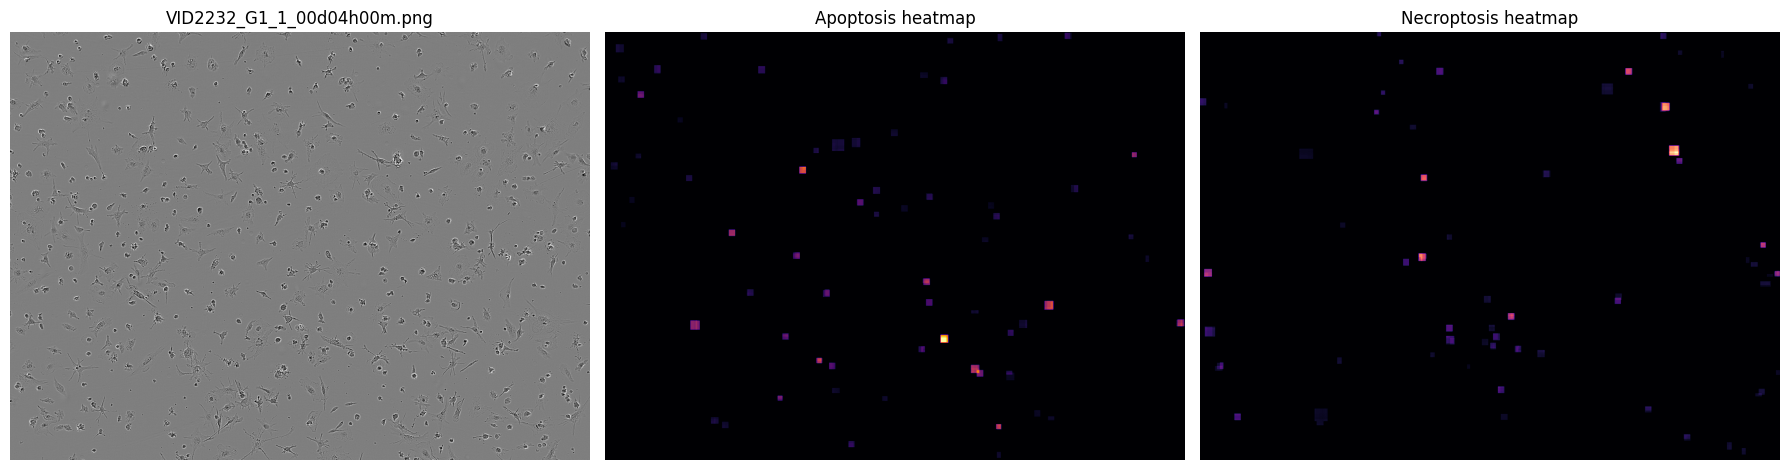

,source_image,label,region_id,area_pixels,bbox_x0,bbox_y0,bbox_x1,bbox_y1,mean_score,max_score,crop_path
0,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_1,137,1273,288,1297,312,0.378235,0.4000,None
1,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_2,256,466,323,494,351,0.589541,0.7000,None
2,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_3,210,295,476,322,502,0.421119,0.4375,None
3,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_4,165,767,594,795,618,0.441926,0.5000,None
4,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_5,415,1062,648,1094,681,0.499424,0.6000,None


In [22]:
detector = CellDetector(MODEL_PATH, image_size=IMAGE_SIZE)
preview_image_path = iter_image_paths(INPUT_DIR, limit=1)[0]
preview = process_image(
    detector=detector,
    image_path=preview_image_path,
    output_dir=OUTPUT_DIR,
    heatmap_threshold=HEATMAP_THRESHOLD,
    min_region_pixels=MIN_REGION_PIXELS,
    padding=PADDING,
    save_crops=False,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(preview["image"], cmap="gray")
axes[0].set_title(preview_image_path.name)
axes[1].imshow(preview["apoptosis_map"], cmap="inferno", vmin=0.0, vmax=1.0)
axes[1].set_title("Apoptosis heatmap")
axes[2].imshow(preview["necroptosis_map"], cmap="magma", vmin=0.0, vmax=1.0)
axes[2].set_title("Necroptosis heatmap")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

preview_df = pd.DataFrame(preview["records"])
preview_df.head()


## Export Dataset

When the preview looks correct, run this cell to export all detected crops and save `metadata.csv`.


In [23]:
metadata = export_dataset(
    detector=detector,
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    limit=LIMIT_IMAGES,
)

print(f"Total exported crops: {len(metadata)}")
if not metadata.empty:
    display(metadata.groupby("label").size().rename("count").to_frame())
    display(metadata.head())


[1/66] VID2232_G1_1_00d04h00m.png: exported 22 crops
[2/66] VID2232_G1_1_00d06h00m.png: exported 39 crops
[3/66] VID2232_G1_1_00d08h00m.png: exported 37 crops
[4/66] VID2232_G1_1_00d10h00m.png: exported 55 crops
[5/66] VID2232_G1_1_00d12h00m.png: exported 48 crops
[6/66] VID2232_G1_1_00d14h00m.png: exported 71 crops
[7/66] VID2232_G1_1_00d16h00m.png: exported 62 crops
[8/66] VID2232_G1_1_00d18h00m.png: exported 65 crops
[9/66] VID2232_G1_1_00d20h00m.png: exported 86 crops
[10/66] VID2232_G1_1_00d22h00m.png: exported 77 crops
[11/66] VID2232_G1_1_01d00h00m.png: exported 73 crops
[12/66] VID2232_G1_2_00d04h00m.png: exported 26 crops
[13/66] VID2232_G1_2_00d06h00m.png: exported 34 crops
[14/66] VID2232_G1_2_00d08h00m.png: exported 26 crops
[15/66] VID2232_G1_2_00d10h00m.png: exported 41 crops
[16/66] VID2232_G1_2_00d12h00m.png: exported 49 crops
[17/66] VID2232_G1_2_00d14h00m.png: exported 68 crops
[18/66] VID2232_G1_2_00d16h00m.png: exported 67 crops
[19/66] VID2232_G1_2_00d18h00m.png: e

,count
label,
apoptosis,2580
necroptosis,1196


,source_image,label,region_id,area_pixels,bbox_x0,bbox_y0,bbox_x1,bbox_y1,mean_score,max_score,crop_path
0,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_1,122,826,11,850,36,0.410214,0.461538,training/ConvNeXt/cropped_data/WT_TC/apoptosis...
1,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_2,253,466,323,494,351,0.446662,0.500000,training/ConvNeXt/cropped_data/WT_TC/apoptosis...
2,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_5,422,1061,648,1094,681,0.611121,0.750000,training/ConvNeXt/cropped_data/WT_TC/apoptosis...
3,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_6,223,1384,694,1408,722,0.441185,0.500000,training/ConvNeXt/cropped_data/WT_TC/apoptosis...
4,examples/ConvNeXt_data_demo/WT_TC/VID2232_G1_1...,apoptosis,region_7,362,203,698,235,729,0.370467,0.400000,training/ConvNeXt/cropped_data/WT_TC/apoptosis...
